In [12]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)
    
class UNET(nn.Module):
    def __init__(
        self, in_channels=3, out_channels=1, features=[64, 128, 256, 512],
    ):
        super(UNET, self).__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down Part of UNET
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature
             
        # Up part of UNET
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature)) 

        self.bottleneck = DoubleConv(features[-1], features[-1]*2) # as it starts from 512
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []
        
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            if x.shape != skip_connection.shape:
                x = TF.resize(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

def test():
    x = torch.randn((3, 1, 161, 161))
    model = UNET(in_channels=1, out_channels=1)
    preds = model(x)
    assert preds.shape == x.shape

if __name__ == "__main__":
    test()

In [13]:
!unzip -q /kaggle/input/competitions/data-science-bowl-2018/stage1_train.zip -d /kaggle/working/stage1_train

replace /kaggle/working/stage1_train/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/images/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [14]:
import os
import numpy as np
from PIL import Image
from torch.utils.data import Dataset

class DSB2018Dataset(Dataset):
    def __init__(self, image_dir, image_ids, transform=None):
        """
        image_dir: Path to the 'stage1_train' folder
        image_ids: List of specific folder names (IDs) to use for this dataset (train or val)
        """
        self.image_dir = image_dir
        self.image_ids = image_ids
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, index):
        folder_id = self.image_ids[index]
        
        # 1. Load the main image
        # Path looks like: stage1_train/xyz123/images/xyz123.png
        img_path = os.path.join(self.image_dir, folder_id, "images", folder_id + ".png")
        
        # DSB images sometimes have 4 channels (RGBA), we force convert to RGB (3 channels)
        image = np.array(Image.open(img_path).convert("RGB"))
        
        # 2. Load and merge all masks
        mask_folder = os.path.join(self.image_dir, folder_id, "masks")
        mask_files = os.listdir(mask_folder)
        
        # Create an empty mask of the exact same dimensions as the image
        mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.float32)
        
        # Loop through every nucleus PNG and merge them into the single mask array
        for mask_file in mask_files:
            mask_path = os.path.join(mask_folder, mask_file)
            single_mask = np.array(Image.open(mask_path).convert("L"), dtype=np.float32)
            
            # Combine current mask with the master mask
            mask = np.maximum(mask, single_mask)
            
        # Convert pixel values to exactly 0.0 or 1.0 
        mask[mask == 255.0] = 1.0

        # Apply Albumentations
        if self.transform is not None:
            augmentations = self.transform(image=image, mask=mask)
            image = augmentations["image"]
            mask = augmentations["mask"]

        return image, mask

In [15]:
import random
from torch.utils.data import DataLoader
import torchvision

def get_loaders(
    train_dir, batch_size, train_transform, val_transform, 
    num_workers=0, pin_memory=True, val_split=0.1
):
    # Get all folder IDs in the stage1_train directory
    all_image_ids = os.listdir(train_dir)
    
    # Shuffle them to ensure random distribution
    random.seed(42)
    random.shuffle(all_image_ids)
    
    # Split into Train and Validation
    split_idx = int(len(all_image_ids) * (1 - val_split))
    train_ids = all_image_ids[:split_idx]
    val_ids = all_image_ids[split_idx:]
    
    print(f"Training on {len(train_ids)} images, Validating on {len(val_ids)} images.")

    # Create datasets passing the specific IDs (calling your Cell 3 class)
    train_ds = DSB2018Dataset(
        image_dir=train_dir, image_ids=train_ids, transform=train_transform,
    )
    val_ds = DSB2018Dataset(
        image_dir=train_dir, image_ids=val_ids, transform=val_transform,
    )

    # Create loaders
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, num_workers=num_workers,
        pin_memory=pin_memory, shuffle=True,
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, num_workers=num_workers,
        pin_memory=pin_memory, shuffle=False,
    )

    return train_loader, val_loader

def check_accuracy(loader, model, device="cuda"):
    num_correct = 0
    num_pixels = 0
    dice_score = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).unsqueeze(1)
            preds = torch.sigmoid(model(x))
            preds = (preds > 0.5).float()
            
            num_correct += (preds == y).sum()
            num_pixels += torch.numel(preds)
            dice_score += (2 * (preds * y).sum()) / (
                (preds + y).sum() + 1e-8
            )

    print(f"Got {num_correct}/{num_pixels} with acc {num_correct/num_pixels*100:.2f}")
    print(f"Dice score: {dice_score/len(loader)}")
    model.train()

def save_predictions_as_images(loader, model, folder="saved_images/", device="cuda"):
    # Create the folder if it doesn't exist
    if not os.path.exists(folder):
        os.makedirs(folder)
        
    model.eval()
    for idx, (x, y) in enumerate(loader):
        x = x.to(device=device)
        with torch.no_grad():
            preds = torch.sigmoid(model(x))
            preds = (preds > 0.5).float()
        torchvision.utils.save_image(preds, f"{folder}/pred_{idx}.png")
        torchvision.utils.save_image(y.unsqueeze(1), f"{folder}/{idx}.png")
        
        # Just save the first batch to save time/space
        break 
        
    model.train()

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm.notebook import tqdm # Use tqdm.notebook for cleaner progress bars in Jupyter


# HYPERPARAMETERS

LEARNING_RATE = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32  
NUM_EPOCHS = 25           # Start with 3-5 to prototype quickly
NUM_WORKERS = 0          # Keep at 0 to prevent Jupyter from freezing
IMAGE_HEIGHT = 256       # Unifying the variable DSB image sizes
IMAGE_WIDTH = 256
PIN_MEMORY = True
TRAIN_IMG_DIR = "stage1_train" # UPDATE THIS PATH if your folder is named differently

# TRAINING FUNCTION (ONE EPOCH)
def train_fn(loader, model, optimizer, loss_fn, scaler):
    loop = tqdm(loader, desc="Training")

    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device=DEVICE)
        # Add channel dimension to targets (B, H, W) -> (B, 1, H, W)
        targets = targets.float().unsqueeze(1).to(device=DEVICE)

        # Forward pass with Automatic Mixed Precision (speeds up training)
        with torch.autocast(device_type=DEVICE if DEVICE == "cuda" else "cpu"):
            predictions = model(data)
            loss = loss_fn(predictions, targets)

        # Backward pass
        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Update tqdm progress bar
        loop.set_postfix(loss=loss.item())


# MAIN EXECUTION BLOCK

# Data Augmentations
train_transform = A.Compose(
    [
        A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
        A.Rotate(limit=35, p=1.0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.Normalize(
            mean=[0.0, 0.0, 0.0],
            std=[1.0, 1.0, 1.0],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ],
)

val_transforms = A.Compose(
    [
        A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),
        A.Normalize(
            mean=[0.0, 0.0, 0.0],
            std=[1.0, 1.0, 1.0],
            max_pixel_value=255.0,
        ),
        ToTensorV2(),
    ],
)

# Initialize Model, Loss, and Optimizer
print(f"Using device: {DEVICE}")
model = UNET(in_channels=3, out_channels=1).to(DEVICE)

# Detect if multiple GPUs are available and wrap the model
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)
    
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Get Data Loaders
train_loader, val_loader = get_loaders(
    train_dir=TRAIN_IMG_DIR,
    batch_size=BATCH_SIZE,
    train_transform=train_transform,
    val_transform=val_transforms,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

scaler = torch.amp.GradScaler('cuda')

# Training Loop
for epoch in range(NUM_EPOCHS):
    print(f"\n--- Epoch {epoch+1}/{NUM_EPOCHS} ---")
    train_fn(train_loader, model, optimizer, loss_fn, scaler)
    
    # Check accuracy and Dice score on the validation set
    check_accuracy(val_loader, model, device=DEVICE)
    
    # Save image samples to check visual progress
    save_predictions_as_images(
        val_loader, model, folder="saved_images", device=DEVICE
    )
    print("Saved sample predictions to 'saved_images' folder.")

Using device: cuda
Using 2 GPUs!
Training on 603 images, Validating on 67 images.

--- Epoch 1/25 ---


Training:   0%|          | 0/19 [00:00<?, ?it/s]

Got 3836864/4390912 with acc 87.38
Dice score: 0.642107367515564
Saved sample predictions to 'saved_images' folder.

--- Epoch 2/25 ---


Training:   0%|          | 0/19 [00:00<?, ?it/s]

Got 4118063/4390912 with acc 93.79
Dice score: 0.759547233581543
Saved sample predictions to 'saved_images' folder.

--- Epoch 3/25 ---


...

Got 4283056/4390912 with acc 97.54
Dice score: 0.902586817741394
Saved sample predictions to 'saved_images' folder.

--- Epoch 24/25 ---


Training:   0%|          | 0/19 [00:00<?, ?it/s]

Got 4288742/4390912 with acc 97.67
Dice score: 0.9057855606079102
Saved sample predictions to 'saved_images' folder.

--- Epoch 25/25 ---


Training:   0%|          | 0/19 [00:00<?, ?it/s]

Got 4296113/4390912 with acc 97.84
Dice score: 0.91047203540802
Saved sample predictions to 'saved_images' folder.


In [28]:
import os
import numpy as np
import pandas as pd
import torch
from PIL import Image
from skimage.measure import label

# 1. Define the Run-Length Encoding function required by Kaggle
def rle_encoding(x):
    dots = np.where(x.T.flatten() == 1)[0]
    run_lengths = []
    prev = -2
    for b in dots:
        if (b > prev+1): run_lengths.extend((b + 1, 0))
        run_lengths[-1] += 1
        prev = b
    return " ".join([str(i) for i in run_lengths])

# 2. Setup paths and initialize submission list
TEST_IMG_DIR = "/kaggle/working/stage1_test"
test_ids = next(os.walk(TEST_IMG_DIR))[1]
submission = []

print(f"Running inference on {len(test_ids)} test images...")
model.eval()

# 3. Loop through test images
for id_ in test_ids:
    im_path = os.path.join(TEST_IMG_DIR, id_, "images", id_ + ".png")
    
    # Read original image to get its true dimensions
    img = Image.open(im_path).convert("RGB")
    original_width, original_height = img.size
    
    # Apply the same transformations used during validation (resizes to 256x256)
    transformed = val_transforms(image=np.array(img))
    img_tensor = transformed["image"].unsqueeze(0).to(DEVICE)
    
    # Predict
    with torch.no_grad():
        with torch.autocast(device_type=DEVICE if DEVICE == "cuda" else "cpu"):
            pred = torch.sigmoid(model(img_tensor))
            pred = (pred > 0.5).float().squeeze().cpu().numpy()
    
    # Resize the prediction back to the original image dimensions
    pred_img = Image.fromarray((pred * 255).astype(np.uint8))
    pred_img_resized = pred_img.resize((original_width, original_height), resample=Image.NEAREST)
    pred_mask = np.array(pred_img_resized) > 127
    
    # 4. Instance Segmentation (Labeling)
    # This separates disconnected blobs into unique instances (1, 2, 3...)
    lab_img = label(pred_mask)
    
    # 5. Encode each distinct cell and add to submission
    if lab_img.max() == 0:
        submission.append([id_, ''])
    else:
        for i in range(1, lab_img.max() + 1):
            submission.append([id_, rle_encoding(lab_img == i)])

# 6. Save to CSV
df = pd.DataFrame(submission, columns=['ImageId', 'EncodedPixels'])
df.to_csv('/kaggle/working/submission.csv', index=False)
print("Inference complete! Saved to 'submission.csv'")

Running inference on 65 test images...
Inference complete! Saved to 'submission.csv'


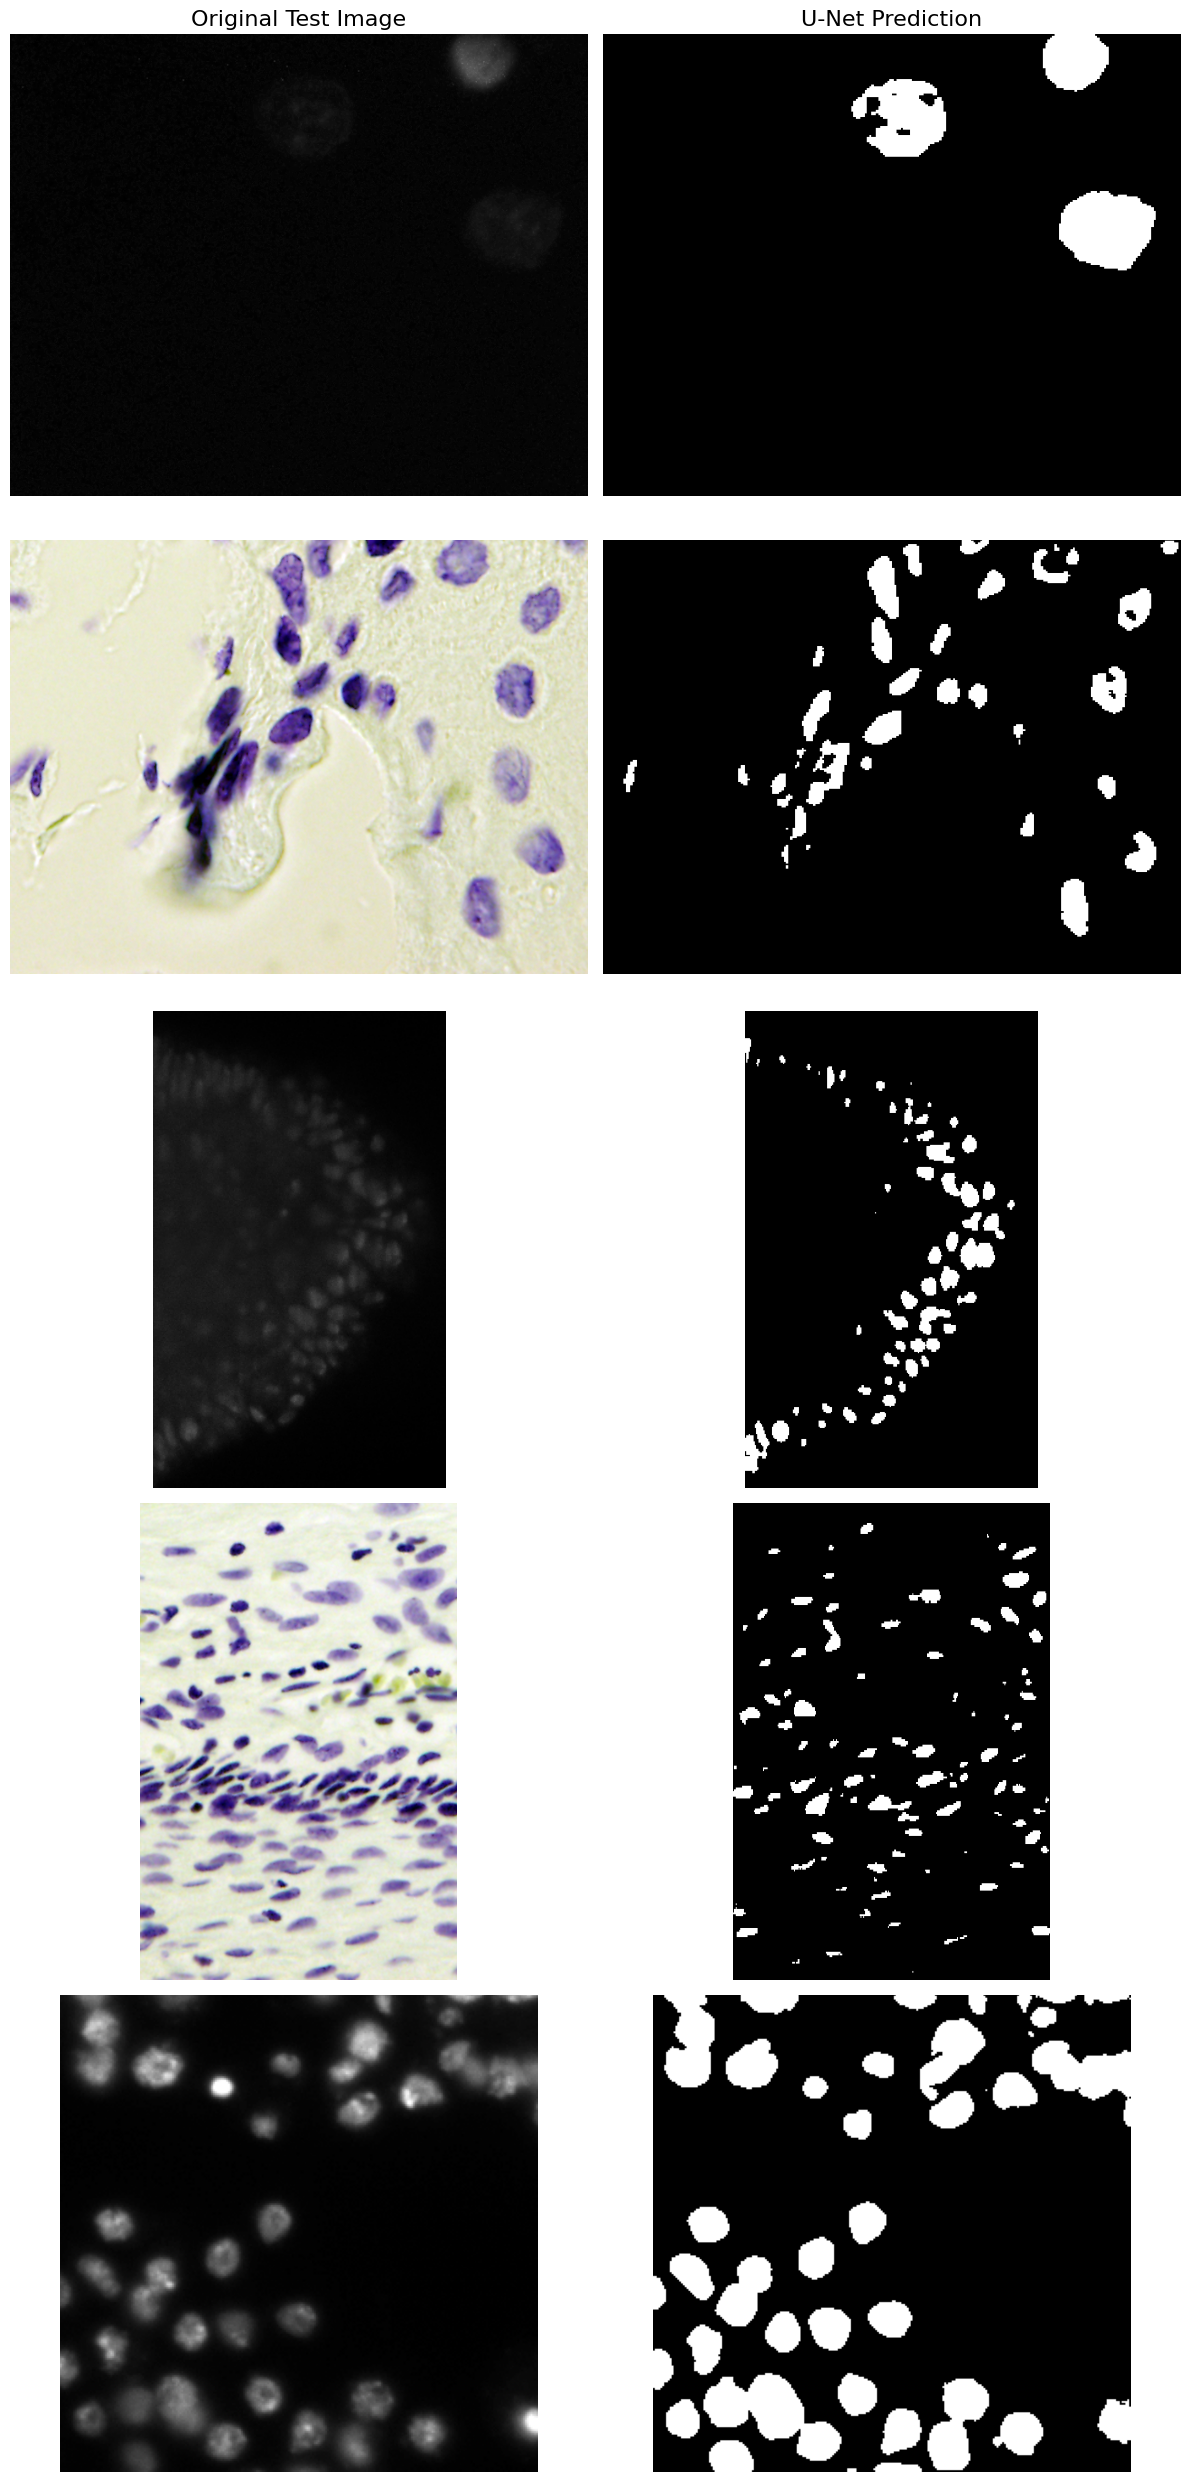

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import torch
from PIL import Image

def display_test_predictions(model, test_dir="/kaggle/working/stage1_test", num_images=4, device="cuda"):
    model.eval()
    
    # Get all test image IDs
    test_ids = next(os.walk(test_dir))[1]
    
    # Pick a few random images to display
    random.seed(42)
    sample_ids = random.sample(test_ids, min(num_images, len(test_ids)))
    
    # Set up the plot grid
    fig, axes = plt.subplots(num_images, 2, figsize=(12, 5 * num_images))
    
    axes[0, 0].set_title("Original Test Image", fontsize=16)
    axes[0, 1].set_title("U-Net Prediction", fontsize=16)
    
    for i, id_ in enumerate(sample_ids):
        # 1. Load Original Image
        im_path = os.path.join(test_dir, id_, "images", id_ + ".png")
        img = Image.open(im_path).convert("RGB")
        original_width, original_height = img.size
        
        # 2. Preprocess and Predict
        transformed = val_transforms(image=np.array(img))
        img_tensor = transformed["image"].unsqueeze(0).to(device)
        
        with torch.no_grad():
            with torch.autocast(device_type=device if device == "cuda" else "cpu"):
                pred = torch.sigmoid(model(img_tensor))
                pred = (pred > 0.5).float().squeeze().cpu().numpy()
        
        # 3. Resize prediction back to original dimensions for accurate plotting
        pred_img = Image.fromarray((pred * 255).astype(np.uint8))
        pred_img_resized = pred_img.resize((original_width, original_height), resample=Image.NEAREST)
        
        # 4. Plot Original
        axes[i, 0].imshow(img)
        axes[i, 0].axis("off")
        
        # 5. Plot Prediction
        axes[i, 1].imshow(np.array(pred_img_resized), cmap="gray")
        axes[i, 1].axis("off")
        
    plt.tight_layout()
    plt.show()
    model.train()

# Run the visualization
display_test_predictions(model, device=DEVICE, num_images=5)